In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (8).zip to archive (8).zip


Saving archive (8).zip to archive (8) (2).zip
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018  

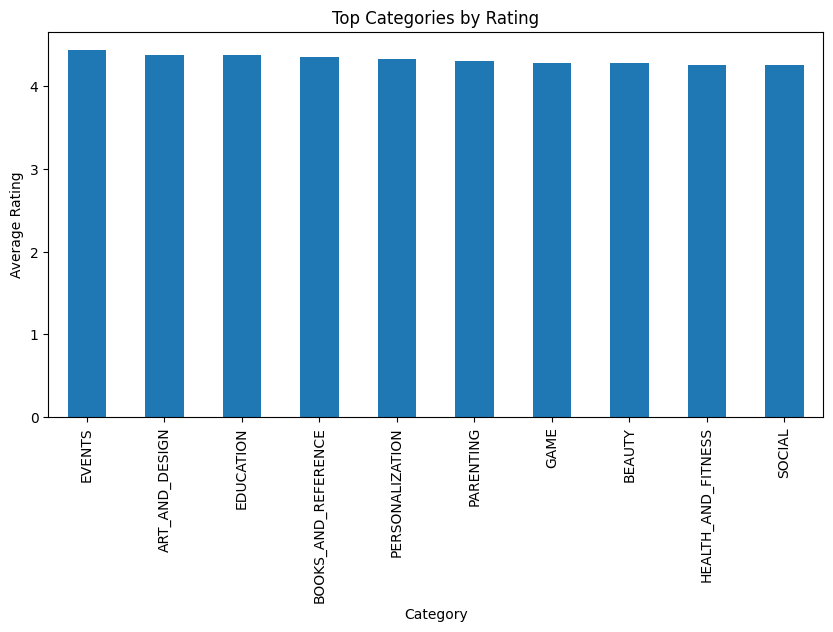

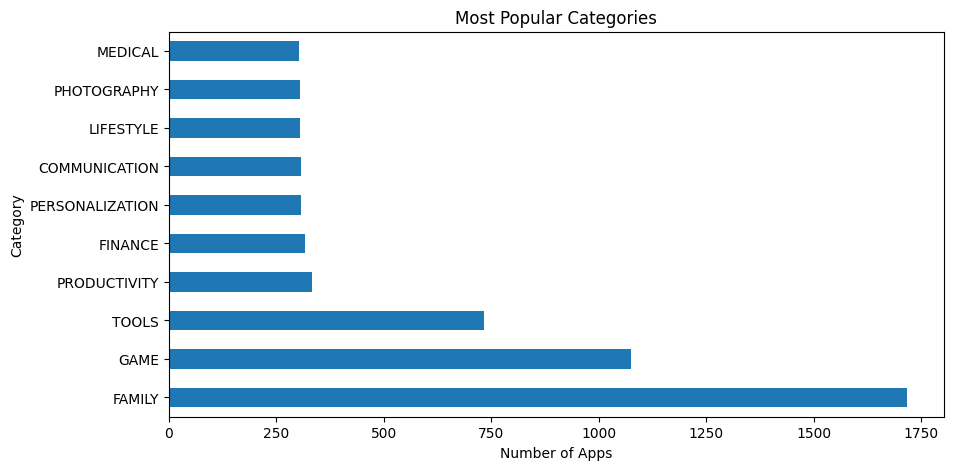

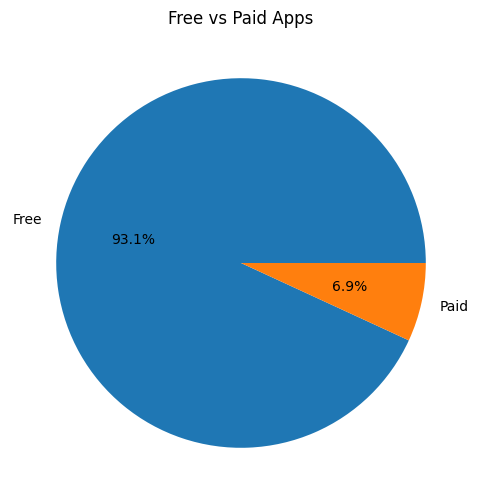

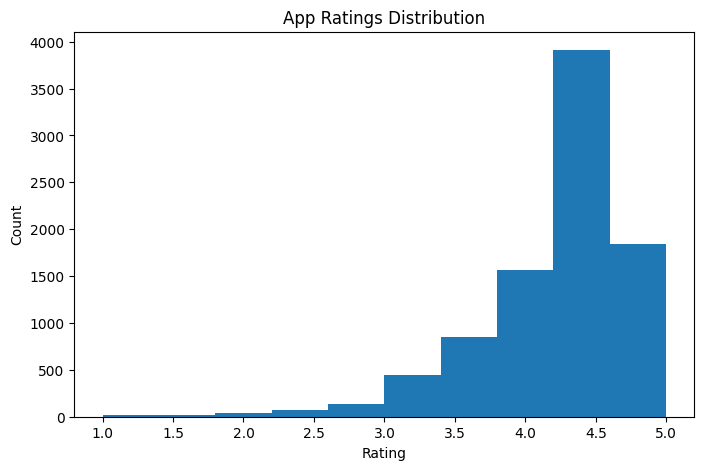


Business Insights Report
-------------------------
Highest Rated Category: EVENTS
Most apps are free applications.
Highly rated categories attract more users.
Focus development on high-performing categories.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import zipfile

uploaded = files.upload()

zip_name = next(iter(uploaded))

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("googleplaystore.csv")

print(df.head())

print(df.info())

print(df.isnull().sum())

df = df.drop_duplicates()

df = df.dropna()

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

top = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top.plot(kind='bar')

plt.title("Top Categories by Rating")

plt.xlabel("Category")

plt.ylabel("Average Rating")

plt.show()

installs = df.groupby('Category')['Reviews'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

installs.plot(kind='barh')

plt.title("Most Popular Categories")

plt.xlabel("Number of Apps")

plt.show()

free_paid = df['Type'].value_counts()

plt.figure(figsize=(6,6))

free_paid.plot(kind='pie', autopct='%1.1f%%')

plt.title("Free vs Paid Apps")

plt.ylabel('')

plt.show()

rating = df['Rating']

plt.figure(figsize=(8,5))

plt.hist(rating)

plt.title("App Ratings Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

best = top.idxmax()

print("\nBusiness Insights Report")
print("-------------------------")
print("Highest Rated Category:", best)
print("Most apps are free applications.")
print("Highly rated categories attract more users.")
print("Focus development on high-performing categories.")